In [6]:
import pandas as pd

In [7]:
from sklearn.metrics import(
                          classification_report,
                           confusion_matrix,
                            f1_score,
                            accuracy_score)

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv(r"D:\ai_customer_intelligence\data\master_final.csv")

In [9]:
df.shape

(158762, 11)

In [10]:
has_comment=df[df['sentiment']!='Sem comentários']

In [11]:
has_comment['sentiment']=has_comment['sentiment'].str.lower().copy()

C:\Users\Asus\AppData\Local\Temp\ipykernel_13408\553061991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  has_comment['sentiment']=has_comment['sentiment'].str.lower().copy()


In [12]:
has_comment

,order_id,product_category_name,price,score,sentiment_score,sentiment,complaint_type,confidence_score,year_month,month,year
0,e481f51cbdc54678b7cc49136f2d6af7,utilidades_domesticas,29.99,4.0,-0.822176,negative,Produto com defeito ou má qualidade,0.826547,2017-10,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,perfumaria,118.70,4.0,0.992790,positive,Sem comentários,0.000000,2018-07,7,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,45.00,5.0,0.000000,neutral,Sem comentários,0.000000,2017-11,11,2017
9,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,99.00,1.0,0.000000,neutral,Sem comentários,0.000000,2017-05,5,2017
10,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,99.00,1.0,0.000000,neutral,Sem comentários,0.000000,2017-05,5,2017
...,...,...,...,...,...,...,...,...,...,...,...
158756,83c1379a015df1e13d02aae0204711ab,eletrodomesticos_2,205.99,5.0,0.000000,neutral,Sem comentários,0.000000,2017-08,8,2017
158757,11c177c8e97725db2631073c19f07b62,informatica_acessorios,179.99,2.0,0.000000,neutral,Sem comentários,0.000000,2018-01,1,2018
158758,11c177c8e97725db2631073c19f07b62,informatica_acessorios,179.99,2.0,0.000000,neutral,Sem comentários,0.000000,2018-01,1,2018
158759,11c177c8e97725db2631073c19f07b62,informatica_acessorios,179.99,2.0,0.000000,neutral,Sem comentários,0.000000,2018-01,1,2018


In [13]:
def stars_to_label(score):
    if score>=4:
        return 'positive'
    elif score==3:
        return 'neutral'
    else:
        return 'negative'


has_comment['true_label']=has_comment['score'].apply(stars_to_label)

C:\Users\Asus\AppData\Local\Temp\ipykernel_13408\1478852183.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  has_comment['true_label']=has_comment['score'].apply(stars_to_label)


In [14]:
has_comment.head()

,order_id,product_category_name,price,score,sentiment_score,sentiment,complaint_type,confidence_score,year_month,month,year,true_label
0,e481f51cbdc54678b7cc49136f2d6af7,utilidades_domesticas,29.99,4.0,-0.822176,negative,Produto com defeito ou má qualidade,0.826547,2017-10,10,2017,positive
1,53cdb2fc8bc7dce0b6741e2150273451,perfumaria,118.70,4.0,0.992790,positive,Sem comentários,0.000000,2018-07,7,2018,positive
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,45.00,5.0,0.000000,neutral,Sem comentários,0.000000,2017-11,11,2017,positive
9,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,99.00,1.0,0.000000,neutral,Sem comentários,0.000000,2017-05,5,2017,negative
10,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,99.00,1.0,0.000000,neutral,Sem comentários,0.000000,2017-05,5,2017,negative


In [15]:
has_comment['predicted_label']=has_comment['sentiment'].str.lower()

C:\Users\Asus\AppData\Local\Temp\ipykernel_13408\3497861570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  has_comment['predicted_label']=has_comment['sentiment'].str.lower()


In [16]:
has_comment.head()

,order_id,product_category_name,price,score,sentiment_score,sentiment,complaint_type,confidence_score,year_month,month,year,true_label,predicted_label
0,e481f51cbdc54678b7cc49136f2d6af7,utilidades_domesticas,29.99,4.0,-0.822176,negative,Produto com defeito ou má qualidade,0.826547,2017-10,10,2017,positive,negative
1,53cdb2fc8bc7dce0b6741e2150273451,perfumaria,118.70,4.0,0.992790,positive,Sem comentários,0.000000,2018-07,7,2018,positive,positive
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,45.00,5.0,0.000000,neutral,Sem comentários,0.000000,2017-11,11,2017,positive,neutral
9,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,99.00,1.0,0.000000,neutral,Sem comentários,0.000000,2017-05,5,2017,negative,neutral
10,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,99.00,1.0,0.000000,neutral,Sem comentários,0.000000,2017-05,5,2017,negative,neutral


In [17]:
print(f"Rows with AI predictions:{len(has_comment):,}")

Rows with AI predictions:95,159


In [18]:
print("\n True Label Values:")
print(has_comment['true_label'].unique())
print("\n True Predicted Values:")
print(has_comment['predicted_label'].unique())


 True Label Values:
['positive' 'negative' 'neutral']

 True Predicted Values:
['negative' 'positive' 'neutral']


In [19]:
labels=['positive','neutral','negative']
y_true=has_comment['true_label']
y_pred=has_comment['predicted_label']


In [20]:
accuracy=accuracy_score(y_true,y_pred)
print(f"\nOverall Accuracy:{accuracy:.3f}({accuracy*100:.1f}%)")


Overall Accuracy:0.635(63.5%)


In [21]:
f1_weighted = f1_score(
    y_true, y_pred,
    labels=labels,
    average='weighted',  # accounts for class imbalance
    zero_division=0
)

f1_macro = f1_score(
    y_true, y_pred,
    labels=labels,
    average='macro',     # treats all classes equally
    zero_division=0
)

In [22]:
print(f"F1 Score (Weighted): {f1_weighted:.3f}")
print(f"F1 Score (Macro):    {f1_macro:.3f}")

# Detailed breakdown per class
print("\nDetailed Classification Report:")
print(classification_report(
    y_true, y_pred,
    labels=labels,
    zero_division=0
))

F1 Score (Weighted): 0.692
F1 Score (Macro):    0.568

Detailed Classification Report:
              precision    recall  f1-score   support

    positive       0.96      0.60      0.74     40753
     neutral       0.15      0.51      0.23      8540
    negative       0.79      0.69      0.74     45866

    accuracy                           0.64     95159
   macro avg       0.63      0.60      0.57     95159
weighted avg       0.80      0.64      0.69     95159



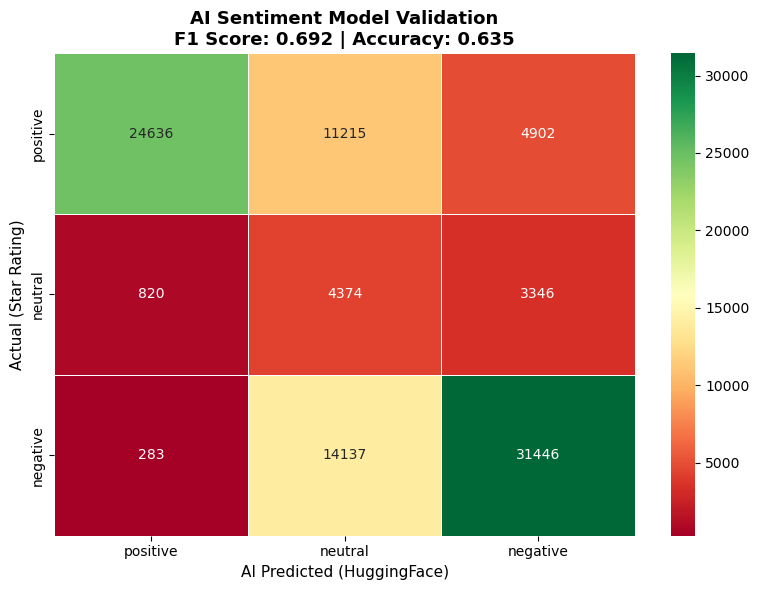

✅ Confusion matrix saved


In [23]:
cm=confusion_matrix(y_true, y_pred,labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='RdYlGn',
            linewidths=0.5)
plt.title(
    f'AI Sentiment Model Validation\n'
    f'F1 Score: {f1_weighted:.3f} | '
    f'Accuracy: {accuracy:.3f}',
    fontsize=13,
    fontweight='bold'
)
plt.ylabel('Actual (Star Rating)', fontsize=11)
plt.xlabel('AI Predicted (HuggingFace)', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("✅ Confusion matrix saved")


In [24]:
import pandas as pd

recommendations = pd.DataFrame({
    'priority': [4, 5, 6, 7, 8],
    'finding': [
        '4,902 hidden dissatisfied customers identified',
        'Wrong item complaints = 30.8% of all complaints',
        'Neutral class underdetection (F1=0.23)',
        'Platform avg health score 56.50 — below threshold',
        '14,137 negative reviews predicted as neutral'
    ],
    'action': [
        'Launch proactive outreach campaign for 4-star customers with negative text',
        'Audit fulfillment and inventory matching process — wrong item rate unacceptable',
        'Supplement AI model with star rating signals for neutral class decisions',
        'Set quarterly health score targets — minimum 10 point improvement per year',
        'Treat model predictions conservatively — actual dissatisfaction likely higher'
    ],
    'impact': [
        'Prevent silent churn — $314,826 revenue protection',
        'Reduce wrong item complaints by 40-50%',
        'Improve model reliability for borderline cases',
        'Platform-wide quality improvement roadmap',
        'More conservative risk estimates — better safety margin'
    ],
    'timeline': [
        '30 days',
        '60 days',
        'Ongoing',
        'Quarterly',
        'Immediate'
    ]
})
,;
recommendations.to_csv(r'D:\ai_customer_intelligence\data\recommendations.csv',
    index=False
)
print("✅ Saved recommendations.csv")

<>:34: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
C:\Users\Asus\AppData\Local\Temp\ipykernel_13408\1122210668.py:34: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
  ("")("")


TypeError: 'str' object is not callable

In [ ]:
import pandas as pd

In [ ]:
df=pd.DataFrame({
        'Metric':['F1 Score (Weighted)','Overall Accuracy','Positve F1','Negative F1','Neutral F1','Reviews Validated'],
         'Value':['0.692','64%','0.74','0.74','0.23','95,159'],
          'Status':['Good','Good','Strong','Strong','Weak','Large']})

In [ ]:
df

In [ ]:
df.to_csv(r'D:\ai_customer_intelligence\data\model_validation_table.csv', index=False)

In [25]:
print(cm)

[[24636 11215  4902]
 [  820  4374  3346]
 [  283 14137 31446]]
